# Quantum pipelines

- `QuantumPipeline` composes stages; the same `Trainer` fits and predicts it.
- `fit_mode="frozen_backbone"`: a fixed 4-class model feeds a trainable head.
- `fit_mode="joint"`: dense, circuit, dense trained end to end as one model.
- Pennylane backend throughout.

### 1. Data

- `make_classification`, 200 samples, 4 features, 2 classes.
- `normalize="minmax"`, fit on train only.
- A pipeline prescales each stage's input itself, so the DataModule only normalizes.

In [7]:
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

import pyqit
from pyqit import DataModule, Trainer
from pyqit.core import PipelineStage, QuantumPipeline
from pyqit.models import VQCClassifier

pyqit.set_backend("pennylane")
pyqit.set_seed(42)

X, y = make_classification(
    n_samples=200, n_features=4, n_informative=4, n_redundant=0, random_state=42
)
dm = DataModule(
    X, y, normalize="minmax", batch_size=16, split=(0.7, 0.15, 0.15), seed=42
)

### 2. Frozen backbone, trainable head

- Stage 1: 4-class `VQCClassifier`, `trainable=False`.
- Stage 2: 2-class `VQCClassifier` head.
- `mode="sequential"` feeds each stage's output to the next; `fit_mode="frozen_backbone"` trains only the head.
- `fit` returns one `TrainingHistory` per trained stage.

In [8]:
backbone = PipelineStage(
    VQCClassifier(n_qubits=4, n_layers=4, n_classes=4),
    name="feature_extractor",
    trainable=False,
)
head = PipelineStage(VQCClassifier(n_qubits=4, n_layers=1), name="classifier")

pipeline = QuantumPipeline(
    [backbone, head], mode="sequential", fit_mode="frozen_backbone"
)
trainer = Trainer(max_epochs=15, learning_rate=0.2)
histories = trainer.fit(pipeline, datamodule=dm)

preds = trainer.predict(pipeline, datamodule=dm, return_format="numpy")
acc = accuracy_score(dm.y_test, preds)
print(f"Frozen backbone test accuracy: {acc * 100:.2f}%")

[Pipeline] QuantumPipeline | mode=sequential | stages=2 | fit_mode=frozen_backbone

 #  Stage              Model          Qubits  Params  Status    
 1  feature_extractor  VQCClassifier  4       48      frozen    
 2  classifier         VQCClassifier  4       12      trainable

[2/2] Fitting stage 'classifier'

Output()

[Trainer] Training complete.

Frozen backbone test accuracy: 60.00%


### 3. Joint mode

- `DenseLayer` and `QuantumLayer` emit features, `DenseClassifier` is the head.
- `fit_mode="joint"` hands the pipeline to the loop as one model, so the loss at the head trains every stage.
- `weights` is one flat dict, keyed `<stage>.<layer>.<weight>`.
- `check_bp=True` samples the quantum stage's gradients before training.


In [9]:
from pyqit.models.layers import DenseClassifier, DenseLayer, QuantumLayer

hybrid = QuantumPipeline(
    [
        ("pre", DenseLayer(n_features=4, n_out=4, activation="tanh")),
        ("quantum", QuantumLayer(n_qubits=4, n_layers=2)),
        ("head", DenseClassifier(n_features=4)),
    ],
    fit_mode="joint",
)
dm_new = DataModule(
    X, y, normalize="minmax", batch_size=16, split=(0.7, 0.15, 0.15), seed=42
)

trainer_new = Trainer(
    max_epochs=15, learning_rate=0.05, loss_fn="cross_entropy", check_bp=True
)
history_new = trainer_new.fit(hybrid, datamodule=dm_new)

print(list(hybrid.weights))

[Pipeline] QuantumPipeline | mode=sequential | stages=3 | fit_mode=joint

 #  Stage    Model            Qubits  Params  Status    
 1  pre      DenseLayer       N/A     20      trainable 
 2  quantum  QuantumLayer     4       24      trainable 
 3  head     DenseClassifier  N/A     5       trainable

Output()


               BP Diagnostic Result : BARREN PLATEAU               
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Metric / Layer                      ┃    Value ┃         Status ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ Qubits                              │        4 │                │
│ Samples                             │      200 │                │
│ Circuit Executions                  │      200 │                │
│ Expected Variance                   │ 5.21e-03 │       Baseline │
│ Quantum Variance                    │ 7.39e-04 │ BARREN PLATEAU │
│ Classical Variance                  │ 7.44e-03 │            N/A │
├─────────────────────────────────────┼──────────┼────────────────┤
│ Layer: quantum.main_circuit.weights │   0.142x │      ← plateau │
│ Layer: pre.dense.weight             │   0.810x │      ← plateau │
│ Layer: pre.dense.bias               │   2.781x │        Healthy │
│ Layer: head.dense.weight            │   1.997

[Trainer] Training complete.

['pre.dense.weight', 'pre.dense.bias', 'quantum.main_circuit.weights', 'head.dense.weight', 'head.dense.bias']


In [10]:
preds_new = trainer_new.predict(hybrid, datamodule=dm_new, return_format="numpy")
acc_new = accuracy_score(dm_new.y_test, preds_new)
print(f"Joint pipeline test accuracy: {acc_new * 100:.2f}%")

Joint pipeline test accuracy: 66.67%


### 4. The same network as a hybrid model

- `DressedQuantumClassifier` (Mari et al. 2020) is this dense, circuit, dense network prebuilt, with the pipeline inside `forward`.
- It takes `n_features` instead of an encoder and is fit like any other model.
- Its weights are the layers', under `pre_net.*`, `quantum.*` and `post_net.*`.

In [11]:
from pyqit.models import DressedQuantumClassifier

dressed = DressedQuantumClassifier(n_features=4, n_qubits=4, n_layers=2)
history_dressed = Trainer(
    max_epochs=15, learning_rate=0.05, loss_fn="cross_entropy"
).fit(dressed, datamodule=DataModule(X, y, normalize="minmax", batch_size=16, seed=42))

print(list(dressed.weights))

 Parameter             Value                    
 Model Name            DressedQuantumClassifier 
 Type                  hybrid classifier        
 Backend               Pennylane                
 Qubits                4                        
 Ansatz                N/A                      
 Encoder               N/A                      
 Trainable Params      33                       
 Device                default.qubit            
 Diff Method           backprop                 
 Optimizer             ADAM                     
 Learning Rate         0.05                     
 Train / Val Samples   140 / 30                 

Output()

[Trainer] Training complete.

['pre_net.weight', 'pre_net.bias', 'quantum.weights', 'post_net.weight', 'post_net.bias']


### 5. Loss curves

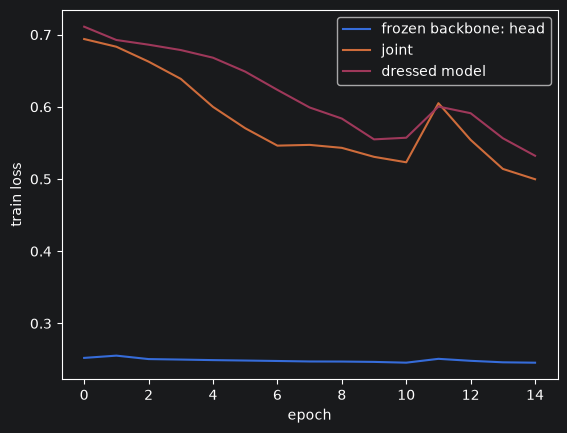

In [12]:
import matplotlib.pyplot as plt

plt.plot(histories["classifier"].train_loss, label="frozen backbone: head")
plt.plot(history_new.train_loss, label="joint")
plt.plot(history_dressed.train_loss, label="dressed model")
plt.xlabel("epoch")
plt.ylabel("train loss")
plt.legend()
plt.show()